# Loading a Dataset

In [ ]:
!wget https://pjreddie.com/media/files/mnist_train.csv
!wget https://pjreddie.com/media/files/mnist_test.csv

--2023-10-01 12:07:56--  https://pjreddie.com/media/files/mnist_train.csv
Resolving pjreddie.com (pjreddie.com)... 128.208.4.108
Connecting to pjreddie.com (pjreddie.com)|128.208.4.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109575994 (104M) [application/octet-stream]
Saving to: ‘mnist_train.csv’

mnist_train.csv     100%[===================>] 104.50M  24.5MB/s    in 5.3s    

2023-10-01 12:08:02 (19.8 MB/s) - ‘mnist_train.csv’ saved [109575994/109575994]

--2023-10-01 12:08:02--  https://pjreddie.com/media/files/mnist_test.csv
Resolving pjreddie.com (pjreddie.com)... 128.208.4.108
Connecting to pjreddie.com (pjreddie.com)|128.208.4.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18289443 (17M) [application/octet-stream]
Saving to: ‘mnist_test.csv’

mnist_test.csv      100%[===================>]  17.44M  9.93MB/s    in 1.8s    

2023-10-01 12:08:04 (9.93 MB/s) - ‘mnist_test.csv’ saved [18289443/18289443]



# Import library

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset,DataLoader,random_split

In [ ]:
data =

In [ ]:
print(data.shape)

(9999, 785)


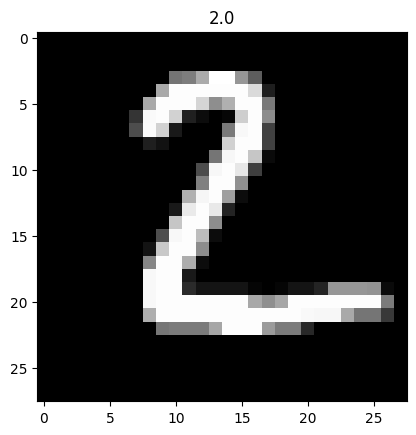

In [ ]:
class MNISTDataset(Dataset):
    def __init__(self,path):
        data = np.genfromtxt(path,delimiter=',',skip_header=1,dtype=np.float32)
        self.features = torch.from_numpy(data[:,1:])
        self.labels = torch.from_numpy(data[:,0].astype(int))
        self.n_samples = data.shape[0]
    def __getitem__(self,index):
        return  self.features[index]/255,self.labels[index].item()
    def __len__(self):
        return self.n_samples

In [ ]:
test_data = MNISTDataset('mnist_test.csv')
train_data = MNISTDataset('mnist_train.csv')

In [ ]:
img,label = train_data[75]

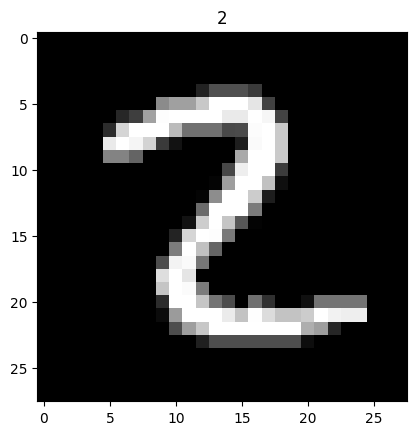

In [ ]:
plt.imshow(img.reshape(28,28),cmap='gray')
plt.title(str(label))
plt.show()


In [ ]:
train_dataloader = DataLoader(train_data,batch_size=1000,shuffle=True)
test_dataloader = DataLoader(test_data,batch_size=1000,shuffle=True)

# Neural Network Models

In [ ]:
# MNIST Model
class Net(torch.nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_features=input, out_features=256)
        self.fc2 = torch.nn.Linear(in_features=256, out_features=128)
        self.fc3 = torch.nn.Linear(in_features=128, out_features=32)
        self.fc4 = torch.nn.Linear(in_features=32, out_features=output)
        self.relu = torch.nn.ReLU()
        self.softmax =torch.nn.Softmax(dim=1)
        # Activation function


    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))

        out = self.softmax(self.fc4(x))
        return out


In [ ]:
model = Net(input=784,output=10)

In [ ]:
# Set the learning rate for the optimizer
learning_rate = 0.001

# Define the loss function (criterion) for the classification task
criterion =nn.CrossEntropyLoss()

# Initialize the optimizer using the Adam optimization algorithm
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

# TRAIN LOOP

In [ ]:
epochs = 5
total_step = len(train_dataloader)

for epoch in range(epochs):
    sum_loss = 0
    sum_acc = 0
    for i,(train_x,train_y) in enumerate(train_dataloader):
        optimizer.zero_grad()
        # forward
        outputs = model(train_x)
        # loss
        loss = criterion(outputs,train_y)
        sum_loss+=loss.item()
        corrects = (outputs.argmax(axis=1)==train_y).sum().item()
        sum_acc+=corrects/train_y.size(0)
        # backward
        loss.backward()

        optimizer.step()
    train_loss=sum_loss/total_step
    train_acc = sum_acc/total_step
    print(f'Epoch[{epoch+1}/{epochs}] \t loss: {train_loss:0.5f} \t accuracy:{train_acc} ')


Epoch[1/5] 	 loss: 1.96272 	 accuracy:0.5674792292292293 
Epoch[2/5] 	 loss: 1.67037 	 accuracy:0.8023299799799801 
Epoch[3/5] 	 loss: 1.63094 	 accuracy:0.8348974974974974 
Epoch[4/5] 	 loss: 1.61863 	 accuracy:0.8460473807140473 
Epoch[5/5] 	 loss: 1.61070 	 accuracy:0.853881064397731 
